In [2]:
import pandas as pd

# Load the uploaded Excel file to check its structure
file_path = '../dataset/rab94row.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows to understand the structure
data.head()

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi
0,Gedung Apartemen,871000000000,606,DKI Jakarta,2021,68204.25309,6,120.020872,31,121.42,109.64,1.53
1,Gedung Apartemen,876000000000,605,DKI Jakarta,2021,68590.48909,6,120.617753,31,121.42,109.64,1.53
2,Gedung Apartemen,936000000000,649,DKI Jakarta,2020,73232.95902,6,128.564830,33,116.84,103.68,1.59
3,Gedung Apartemen,938000000000,628,DKI Jakarta,2020,73318.17099,6,128.882451,33,116.84,103.68,1.59
4,Gedung Apartemen,1050000000000,668,DKI Jakarta,2020,81640.56895,6,142.594757,36,116.84,103.68,1.59


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor, StackingRegressor, VotingRegressor
from sklearn.linear_model import BayesianRidge, Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [4]:
import numpy as np

numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Retry applying log transformation with numpy properly imported
transformed_data = data.copy()
for col in numerical_columns:
    transformed_data[col] = data[col].apply(lambda x: np.log1p(x) if x > 0 else x)

In [5]:
transformed_data.head()

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi
0,Gedung Apartemen,27.492908,6.408529,DKI Jakarta,7.611842,11.130277,1.94591,4.795963,3.465736,4.807458,4.706282,0.928219
1,Gedung Apartemen,27.498632,6.406880,DKI Jakarta,7.611842,11.135924,1.94591,4.800883,3.465736,4.807458,4.706282,0.928219
2,Gedung Apartemen,27.564881,6.476972,DKI Jakarta,7.611348,11.201415,1.94591,4.864181,3.526361,4.769328,4.650908,0.951658
3,Gedung Apartemen,27.567016,6.444131,DKI Jakarta,7.611348,11.202577,1.94591,4.866630,3.526361,4.769328,4.650908,0.951658
4,Gedung Apartemen,27.679811,6.505784,DKI Jakarta,7.611348,11.310094,1.94591,4.966995,3.610918,4.769328,4.650908,0.951658


In [6]:
cekduplikat = transformed_data[transformed_data.duplicated()]
cekduplikat

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi


In [7]:
transformed_data = transformed_data.drop_duplicates()

cekduplikat = transformed_data[transformed_data.duplicated()]
cekduplikat, transformed_data.shape

(Empty DataFrame
 Columns: [namaproyek, rab, waktu, provinsi, tahun, luas, subitem, tinggi, lantai, ikk, ihbp, inflasi]
 Index: [],
 (94, 12))

In [8]:
# Fungsi untuk mendeteksi outlier menggunakan metode IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analisis outlier untuk setiap kolom numerik
outlier_results = {}
for col in numerical_columns:
    outliers, lower, upper = detect_outliers_iqr(transformed_data, col)
    outlier_results[col] = {
        "outliers_count": len(outliers),
        "lower_bound": lower,
        "upper_bound": upper
    }

# Menampilkan hasil analisis outlier
outlier_results

{'rab': {'outliers_count': 4,
  'lower_bound': 27.226348212429848,
  'upper_bound': 27.996962523847053},
 'waktu': {'outliers_count': 1,
  'lower_bound': 6.276350172435078,
  'upper_bound': 6.664825557243586},
 'tahun': {'outliers_count': 0,
  'lower_bound': 7.60788543037709,
  'upper_bound': 7.615798390425516},
 'luas': {'outliers_count': 4,
  'lower_bound': 10.874644684051724,
  'upper_bound': 11.6179529767102},
 'subitem': {'outliers_count': 1,
  'lower_bound': 1.9459101490553132,
  'upper_bound': 1.9459101490553132},
 'tinggi': {'outliers_count': 2,
  'lower_bound': 4.565729729459754,
  'upper_bound': 5.231677846300954},
 'lantai': {'outliers_count': 1,
  'lower_bound': 3.207960517409738,
  'upper_bound': 3.8953615451163746},
 'ikk': {'outliers_count': 0,
  'lower_bound': 4.47807790014296,
  'upper_bound': 4.922348350649209},
 'ihbp': {'outliers_count': 0,
  'lower_bound': 4.255595659957586,
  'upper_bound': 5.406323949764713},
 'inflasi': {'outliers_count': 7,
  'lower_bound': 0.7

In [9]:
# Fungsi untuk mendeteksi dan menghapus baris yang mengandung outlier
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hapus baris yang memiliki nilai outlier
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Hapus outlier untuk setiap kolom numerik
data_cleaned = transformed_data.copy()
for col in numerical_columns:
    data_cleaned = remove_outliers_iqr(data_cleaned, col)

In [10]:
data_cleaned.shape

(82, 12)

In [11]:
# Label encoding kolom 'Provinsi' dan nama proyek karena nilainya kategorikal
label_encoder = LabelEncoder()
data_cleaned['label_provinsi'] = label_encoder.fit_transform(data_cleaned['provinsi'])
data_cleaned['label_namaproyek'] = label_encoder.fit_transform(data_cleaned['namaproyek'])

# Melihat nilai unik dari hasil encoding kolom 'provinsi_encoded'
provinsi_unik = data_cleaned[['provinsi', 'label_provinsi']].drop_duplicates().sort_values(
    by='label_provinsi')

# Melihat nilai unik dari hasil encoding kolom 'namaproyek_encoded'
namaproyek_unik = data_cleaned[['namaproyek', 'label_namaproyek']].drop_duplicates().sort_values(
    by='label_namaproyek')

In [12]:
provinsi_unik

,provinsi,label_provinsi
90,Bali,0
77,Banten,1
0,DKI Jakarta,2
39,Jawa Barat,3
68,Jawa Timur,4
85,Kalimantan Timur,5


In [13]:
namaproyek_unik

,namaproyek,label_namaproyek
0,Gedung Apartemen,0


In [14]:
# 4. Normalisasi Kolom Numerik
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

numerical_columns = ['waktu', 'tahun', 'luas', 'subitem', 
                     'tinggi', 'lantai', 'ikk', 'ihbp', 'inflasi']
# 4. Normalisasi Kolom Numerik
scalerMinMax = MinMaxScaler()
data_cleaned[numerical_columns] = scalerMinMax.fit_transform(data_cleaned[numerical_columns])

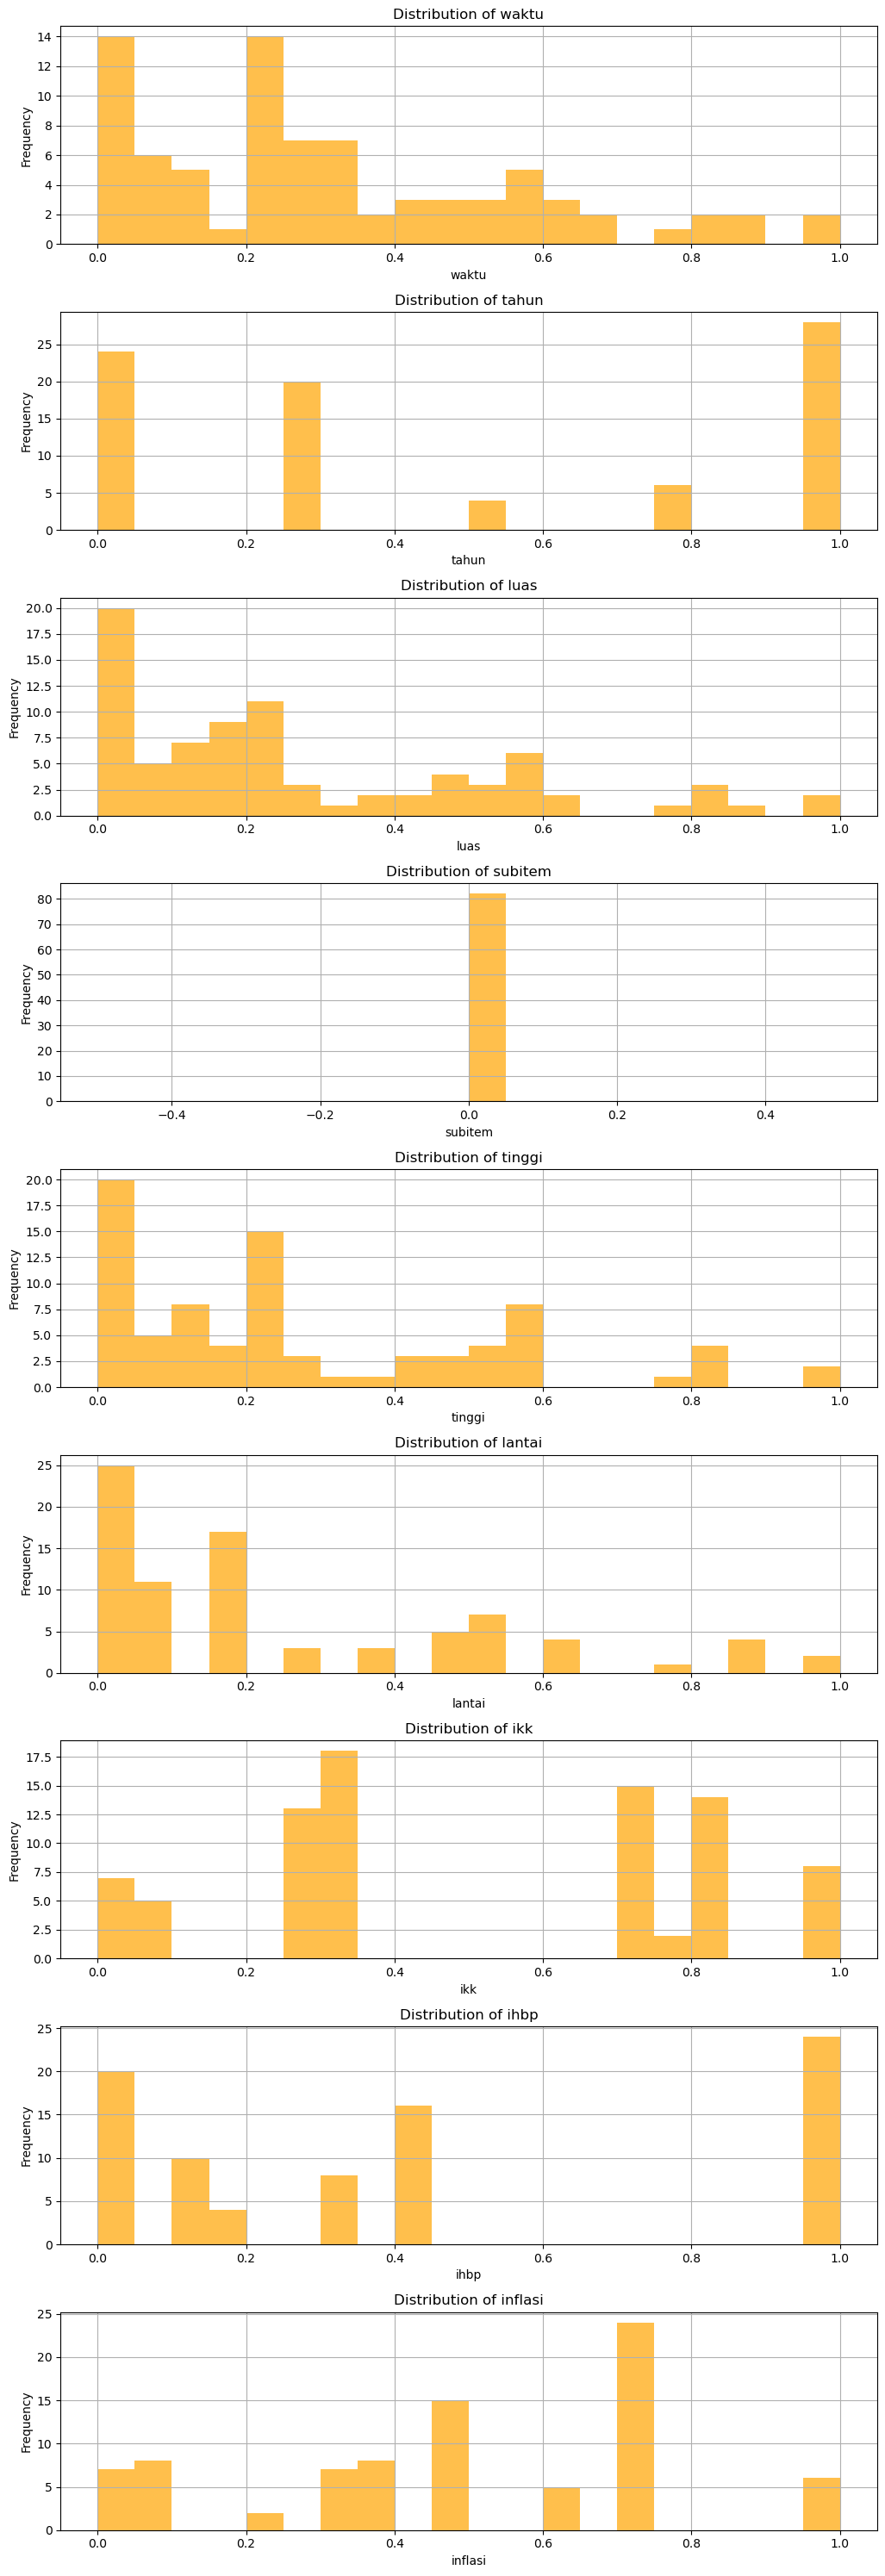

In [15]:
# Compare distributions before and after transformation using histograms
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_columns, 1):

    # Transformed data
    plt.subplot(len(numerical_columns), 2, 2 * i)
    data_cleaned[col].hist(bins=20, alpha=0.7, color='orange')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

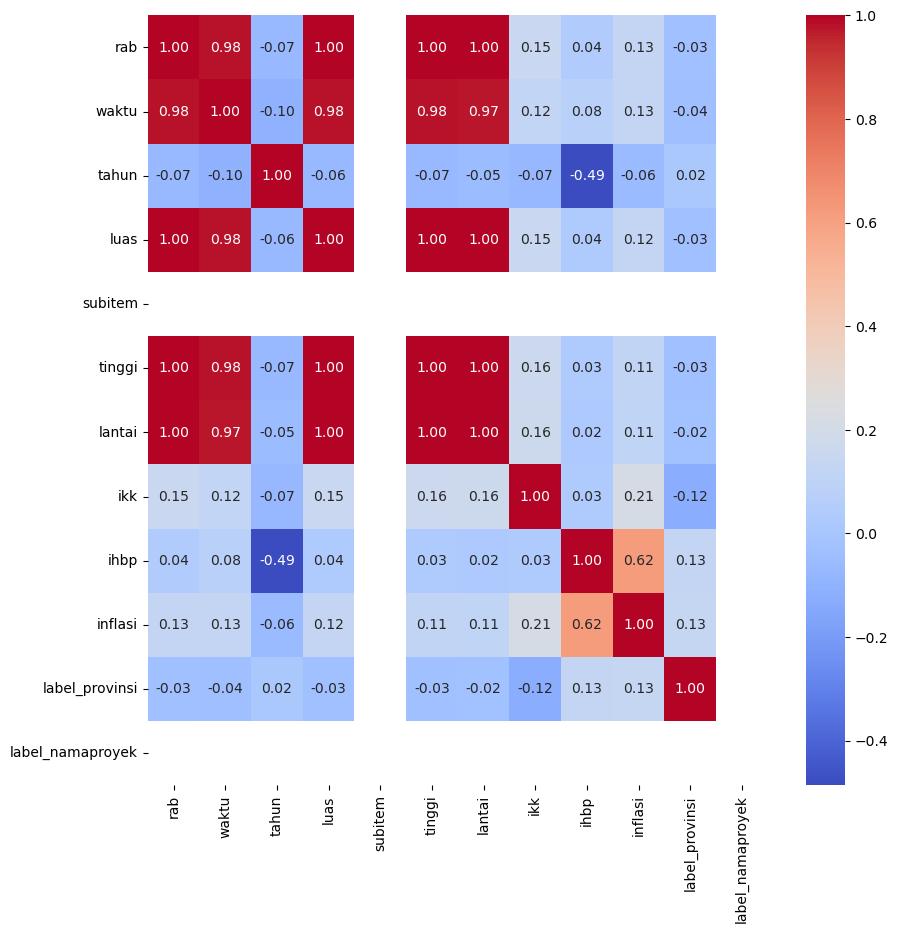

In [16]:
# Digunakan untuk membuat visualisasi dalam bentuk grafik atau plot
import seaborn as sns
import matplotlib.pyplot as plt
# Visualisasi korelasi antar fitur atau kolom apakah saling berpengaruh atau tidak
fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(data_cleaned.corr(numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.show()

In [17]:
# Split data into features and target
X1 = data_cleaned.drop(columns=[
    'rab', 'namaproyek', 'provinsi', 'lantai'])
y1 = data_cleaned['rab']

# Split into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, 
    test_size=0.3, 
    random_state=42)

# Split into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y1, 
    test_size=0.2, 
    random_state=42)

In [23]:
from sklearn.pipeline import make_pipeline

# 2. Definisi model individual

rf = RandomForestRegressor(random_state=42)
ridge = Ridge(random_state=42)
xgboost = xgb.XGBRegressor()
br = BayesianRidge()
gb = GradientBoostingRegressor(random_state=42)
lr = LinearRegression()
adb = AdaBoostRegressor(random_state=42)


meta_model = LinearRegression()

# 3. Membuat Stacking Regressor
stacking_regressor = StackingRegressor(
   estimators=[
        ('br', br),
        ('lr', lr),
        # ('adb', adb),
        # ('gb', gb),
        # ('rf', rf),
        # ('ridge', ridge),
        # ('xgboost', xgboost),
    ],
    final_estimator=meta_model)

# 4. Melatih Stacking Regressor
stacking_regressor.fit(X_train1, y_train1)

# Training
y_train_pred_stacking = stacking_regressor.predict(X_train1)
mae_train_stacking = mean_absolute_error(y_train1, y_train_pred_stacking)
rmse_train_stacking = np.sqrt(mean_squared_error(y_train1, y_train_pred_stacking))
r2_train_stacking = r2_score(y_train1, y_train_pred_stacking)

# Testing
y_test_pred_stacking = stacking_regressor.predict(X_test1)
mae_test_stacking = mean_absolute_error(y_test1, y_test_pred_stacking)
rmse_test_stacking = np.sqrt(mean_squared_error(y_test1, y_test_pred_stacking))
r2_test_stacking = r2_score(y_test1, y_test_pred_stacking)

print("Training")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_train_stacking))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_train_stacking))
print(f"R² Score: ", "{:.3f}".format(r2_train_stacking))
print("="*80)
print("Testing")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_test_stacking))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_test_stacking))
print(f"R² Score: ", "{:.3f}".format(r2_test_stacking))

Training
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.001
R² Score:  1.000
Testing
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.002
R² Score:  1.000


In [27]:
from sklearn.pipeline import make_pipeline

# 3. Membuat Voting Regressor
voting_regressor = VotingRegressor(
   estimators=[
        ('br', br),
        ('lr', lr),
        # ('adb', adb),
        # ('gb', gb),
        # ('rf', rf),
        # ('ridge', ridge),
        # ('xgboost', xgboost),
    ])

# 4. Melatih Voting Regressor
voting_regressor.fit(X_train1, y_train1)

# Training
y_train_pred_voting = voting_regressor.predict(X_train1)
mae_train_voting = mean_absolute_error(y_train1, y_train_pred_voting)
rmse_train_voting = np.sqrt(mean_squared_error(y_train1, y_train_pred_voting))
r2_train_voting = r2_score(y_train1, y_train_pred_voting)

# Testing
y_test_pred_voting = voting_regressor.predict(X_test1)
mae_test_voting = mean_absolute_error(y_test1, y_test_pred_voting)
rmse_test_voting = np.sqrt(mean_squared_error(y_test1, y_test_pred_voting))
r2_test_voting = r2_score(y_test1, y_test_pred_voting)

print("Training")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_train_voting))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_train_voting))
print(f"R² Score: ", "{:.3f}".format(r2_train_voting))
print("="*80)
print("Testing")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_test_voting))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_test_voting))
print(f"R² Score: ", "{:.3f}".format(r2_test_voting))

Training
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.001
R² Score:  1.000
Testing
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.002
R² Score:  1.000


In [28]:
from sklearn.pipeline import make_pipeline

# 2. Definisi model individual

rf2 = RandomForestRegressor(random_state=42)
ridge2 = Ridge(random_state=42)
xgboost2 = xgb.XGBRegressor()
br2 = BayesianRidge()
gb2 = GradientBoostingRegressor(random_state=42)
lr2 = LinearRegression()
adb2 = AdaBoostRegressor(random_state=42)
knn2 = KNeighborsRegressor()
svr2 = SVR()


meta_model2 = LinearRegression()

# 3. Membuat Stacking Regressor
stacking_regressor2 = StackingRegressor(
   estimators=[
        ('br', br),
        ('lr', lr),
        # ('adb', adb),
        # ('gb', gb),
        # ('rf', rf),
        # ('ridge', ridge),
        # ('xgboost', xgboost),
    ],
    final_estimator=meta_model2)

# 4. Melatih Stacking Regressor
stacking_regressor2.fit(X_train2, y_train2)

# Training
y_train_pred_stacking2 = stacking_regressor2.predict(X_train2)
mae_train_stacking2 = mean_absolute_error(y_train2, y_train_pred_stacking2)
rmse_train_stacking2 = np.sqrt(mean_squared_error(y_train2, y_train_pred_stacking2))
r2_train_stacking2 = r2_score(y_train2, y_train_pred_stacking2)

# Testing
y_test_pred_stacking2 = stacking_regressor2.predict(X_test2)
mae_test_stacking2 = mean_absolute_error(y_test2, y_test_pred_stacking2)
rmse_test_stacking2 = np.sqrt(mean_squared_error(y_test2, y_test_pred_stacking2))
r2_test_stacking2 = r2_score(y_test2, y_test_pred_stacking2)

print("Training")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_train_stacking2))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_train_stacking2))
print(f"R² Score: ", "{:.3f}".format(r2_train_stacking2))
print("="*80)
print("Testing")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_test_stacking2))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_test_stacking2))
print(f"R² Score: ", "{:.3f}".format(r2_test_stacking2))

Training
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.002
R² Score:  1.000
Testing
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.002
R² Score:  1.000


In [30]:
from sklearn.pipeline import make_pipeline

# 3. Membuat Voting Regressor
voting_regressor2 = VotingRegressor(
   estimators=[
        ('br', br),
        ('lr', lr),
        # ('adb', adb),
        # ('gb', gb),
        # ('rf', rf),
        # ('ridge', ridge),
        # ('xgboost', xgboost),
    ],
    weights=[2, 1])

# 4. Melatih Voting Regressor
voting_regressor2.fit(X_train2, y_train2)

# Training
y_train_pred_voting2 = voting_regressor2.predict(X_train2)
mae_train_voting2 = mean_absolute_error(y_train2, y_train_pred_voting2)
rmse_train_voting2 = np.sqrt(mean_squared_error(y_train2, y_train_pred_voting2))
r2_train_voting2 = r2_score(y_train2, y_train_pred_voting2)

# Testing
y_test_pred_voting2 = voting_regressor2.predict(X_test2)
mae_test_voting2 = mean_absolute_error(y_test2, y_test_pred_voting2)
rmse_test_voting2 = np.sqrt(mean_squared_error(y_test2, y_test_pred_voting2))
r2_test_voting2 = r2_score(y_test2, y_test_pred_voting2)

print("Training")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_train_voting2))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_train_voting2))
print(f"R² Score: ", "{:.3f}".format(r2_train_voting2))
print("="*80)
print("Testing")
print(f"Mean Absolute Error (MAE): ", "{:.3f}".format(mae_test_voting2))
print(f"Root Mean Squared Error (MSE): ", "{:.3f}".format(rmse_test_voting2))
print(f"R² Score: ", "{:.3f}".format(r2_test_voting2))

Training
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.002
R² Score:  1.000
Testing
Mean Absolute Error (MAE):  0.001
Root Mean Squared Error (MSE):  0.002
R² Score:  1.000


In [41]:
# Prediksi nilai actual dan prediksi untuk 70:30
y_actual1 = y_test1
y_pred_best1 = voting_regressor.predict(X_test1)

# Prediksi nilai actual dan prediksi untuk 80:20
y_actual2 = y_test2
y_pred_best2 = voting_regressor2.predict(X_test2)

Voting Regressor 70:30

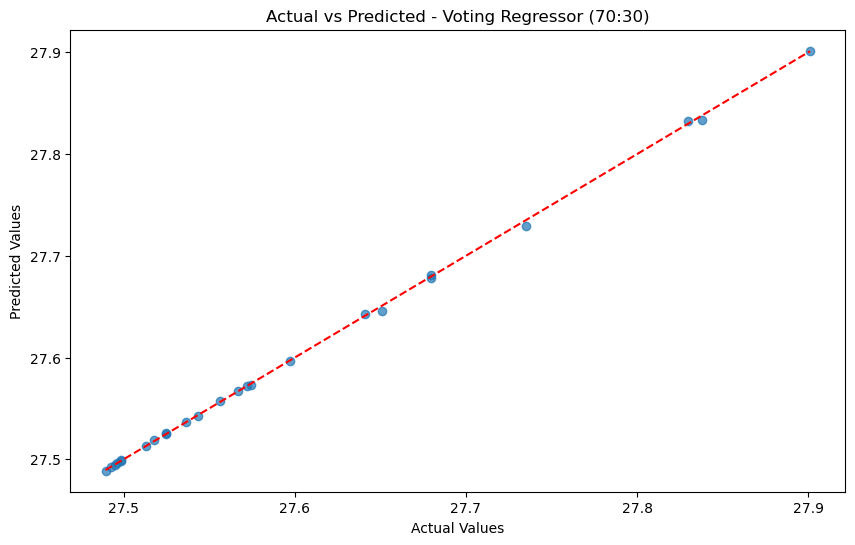

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_actual1, y_pred_best1, alpha=0.7)
plt.plot([y_actual1.min(), y_actual1.max()], [y_actual1.min(), y_actual1.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - Voting Regressor (70:30)")
plt.show()


Voting Regressor 80:20

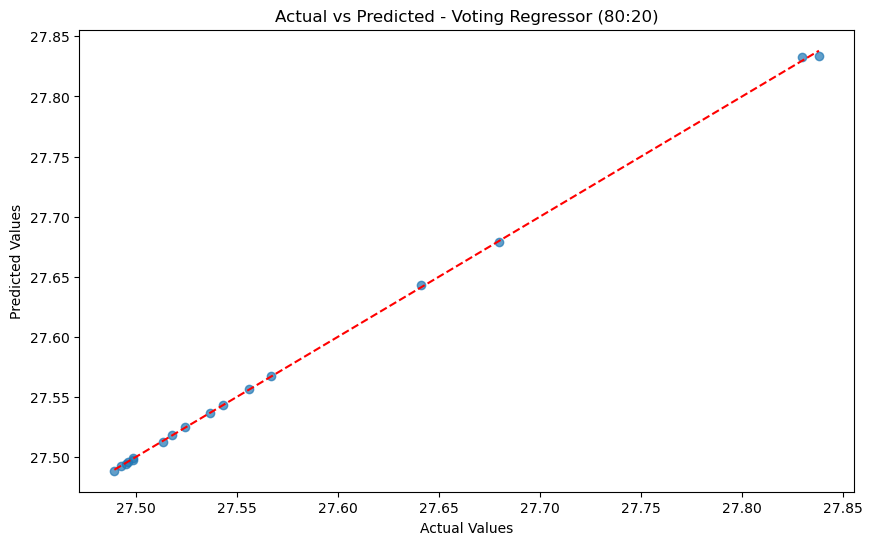

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_actual2, y_pred_best2, alpha=0.7)
plt.plot([y_actual2.min(), y_actual2.max()], [y_actual2.min(), y_actual2.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - Voting Regressor (80:20)")
plt.show()


In [44]:
# Dataframe untuk 70:30
comparison1 = pd.DataFrame({'Actual': y_actual1, 'Predicted': y_pred_best1})

# Dataframe untuk 80:20
comparison2 = pd.DataFrame({'Actual': y_actual2, 'Predicted': y_pred_best2})

# Tampilkan beberapa baris pertama
print(comparison1.head())
print(comparison2.head())


       Actual  Predicted
30  27.838035  27.833321
0   27.492908  27.492309
22  27.556298  27.557274
33  27.567016  27.567075
18  27.517852  27.518766
       Actual  Predicted
30  27.838035  27.833503
0   27.492908  27.492476
22  27.556298  27.556945
33  27.567016  27.567042
18  27.517852  27.518563


In [45]:
# Kembalikan nilai log ke bentuk asli
comparison1['Actual (Original)'] = np.exp(comparison1['Actual'])
comparison1['Predicted (Original)'] = np.exp(comparison1['Predicted'])

comparison2['Actual (Original)'] = np.exp(comparison2['Actual'])
comparison2['Predicted (Original)'] = np.exp(comparison2['Predicted'])

# Format ke dalam Rupiah
def format_rupiah(value):
    return f"Rp {value:,.0f}".replace(",", ".")

comparison1['Actual (Rupiah)'] = comparison1['Actual (Original)'].apply(format_rupiah)
comparison1['Predicted (Rupiah)'] = comparison1['Predicted (Original)'].apply(format_rupiah)

comparison2['Actual (Rupiah)'] = comparison2['Actual (Original)'].apply(format_rupiah)
comparison2['Predicted (Rupiah)'] = comparison2['Predicted (Original)'].apply(format_rupiah)

# Tampilkan beberapa baris pertama
print(comparison1[['Actual (Rupiah)', 'Predicted (Rupiah)']])
print()
print("*" * 100)
print(comparison2[['Actual (Rupiah)', 'Predicted (Rupiah)']])


         Actual (Rupiah)    Predicted (Rupiah)
30  Rp 1.230.000.000.001  Rp 1.224.215.390.120
0     Rp 871.000.000.001    Rp 870.478.217.275
22    Rp 928.000.000.001    Rp 928.906.973.310
33    Rp 938.000.000.001    Rp 938.055.081.271
18    Rp 893.000.000.001    Rp 893.816.351.110
28  Rp 1.010.000.000.001  Rp 1.011.904.411.468
10    Rp 868.000.000.001    Rp 867.438.623.206
57    Rp 889.000.000.001    Rp 888.581.583.355
4   Rp 1.050.000.000.001  Rp 1.047.876.891.517
12    Rp 874.000.000.001    Rp 873.800.105.381
52    Rp 876.000.000.001    Rp 875.501.568.744
35    Rp 876.000.000.001    Rp 876.903.977.923
72    Rp 873.000.000.001    Rp 871.999.037.727
37  Rp 1.220.000.000.001  Rp 1.223.633.587.758
77    Rp 916.000.000.001    Rp 915.349.583.286
48    Rp 910.000.000.001    Rp 910.419.070.958
83    Rp 899.000.000.001    Rp 898.908.998.413
66  Rp 1.050.000.000.001  Rp 1.051.572.459.521
60    Rp 967.000.000.001    Rp 966.598.518.392
42  Rp 1.110.000.000.001  Rp 1.103.493.919.754
9     Rp 943.

Voting Regressor 1

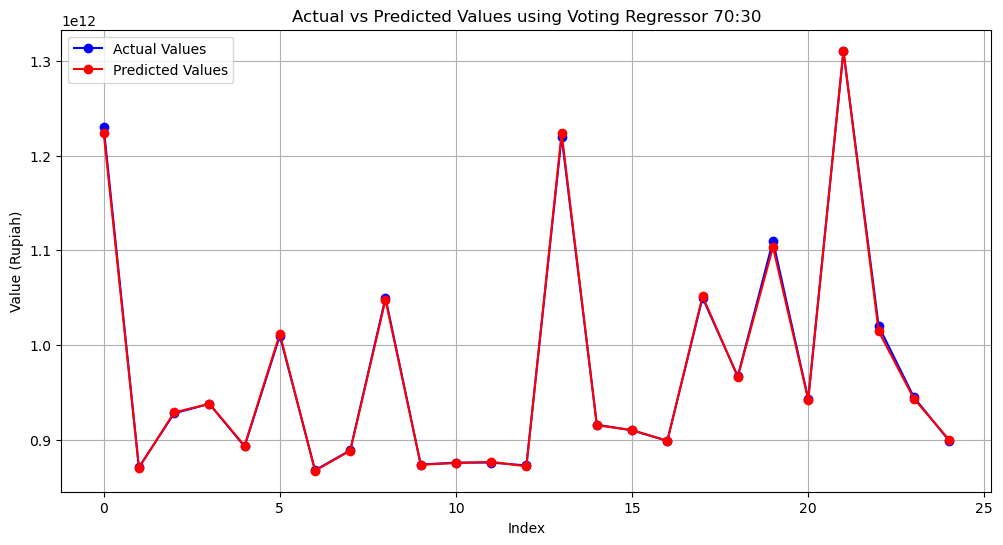

In [46]:
# Predict on the test data
y_pred_log1 = voting_regressor.predict(X_test1)

# If your target variable was log-transformed, revert it back
y_actual1 = np.exp(y_test1.reset_index(drop=True))
y_pred1 = np.exp(y_pred_log1)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_actual1,
    'Predicted': y_pred1
})

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 'bo-', label='Actual Values')
plt.plot(comparison_df.index, comparison_df['Predicted'], 'ro-', label='Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value (Rupiah)')
plt.title(f'Actual vs Predicted Values using Voting Regressor 70:30')
plt.legend()
plt.grid(True)
plt.show()


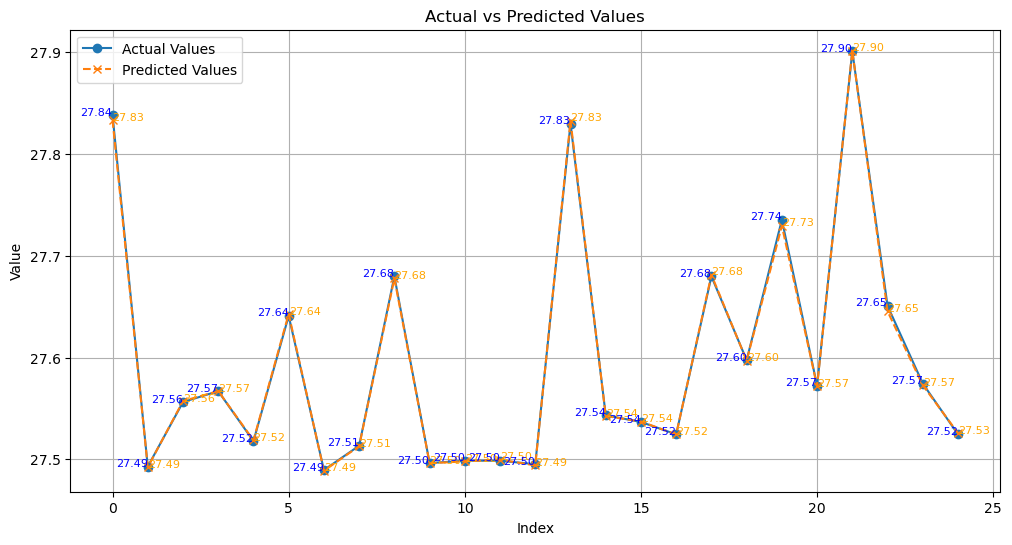

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Pastikan data berbentuk array (jika tidak, ubah dengan np.array)
y_test = np.array(y_test1)  # Nilai aktual
y_pred = np.array(y_pred_log1)  # Nilai prediksi

# Buat plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test, label='Actual Values', marker='o', linestyle='-')
plt.plot(range(len(y_pred)), y_pred, label='Predicted Values', marker='x', linestyle='--')

# Tambahkan angka di setiap titik
for i, (y_actual, y_predict) in enumerate(zip(y_test, y_pred)):
    plt.text(i, y_actual, f'{y_actual:.2f}', fontsize=8, ha='right', color='blue')
    plt.text(i, y_predict, f'{y_predict:.2f}', fontsize=8, ha='left', color='orange')

# Tambahkan label dan judul
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)

# Tampilkan plot
plt.show()

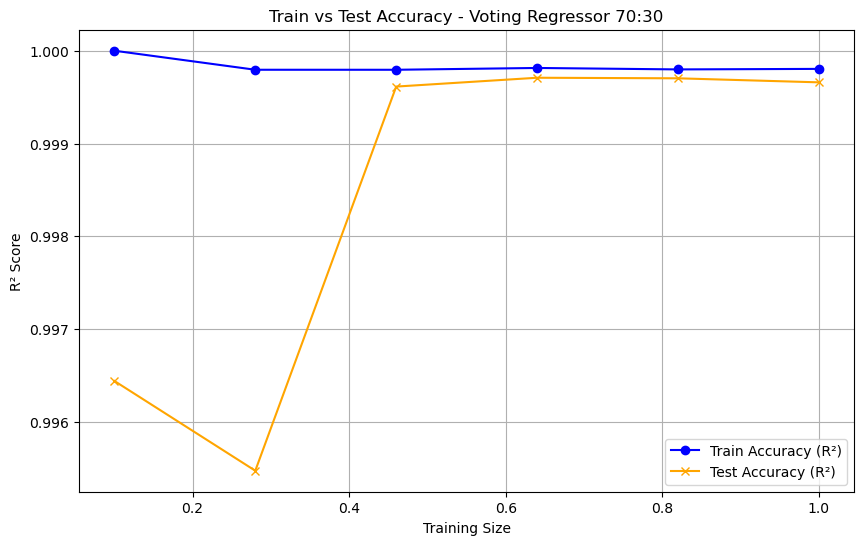

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Training sizes (misalnya dalam persen data training)
training_sizes = np.linspace(0.1, 1.0, 6)

# Menyimpan nilai R² untuk setiap training size
train_accuracies_best = []
test_accuracies_best = []

for size in training_sizes:
    # Tentukan jumlah data training sesuai ukuran
    train_size = int(size * len(X_train1))
    X_train_subset = X_train1[:train_size]
    y_train_subset = y_train1[:train_size]
    
    # Fit model dengan subset data
    voting_regressor.fit(X_train_subset, y_train_subset)
    
    # Prediksi untuk data training dan testing
    y_train_pred = voting_regressor.predict(X_train_subset)
    y_test_pred = voting_regressor.predict(X_test1)
    
    # Hitung R² Score
    train_accuracies_best.append(r2_score(y_train_subset, y_train_pred))
    test_accuracies_best.append(r2_score(y_test1, y_test_pred))

# Plot Train vs Test Accuracy khusus model terbaik
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, train_accuracies_best, 'bo-', label='Train Accuracy (R²)')
plt.plot(training_sizes, test_accuracies_best, 'x-', color='orange', label='Test Accuracy (R²)')
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.title(f'Train vs Test Accuracy - Voting Regressor 70:30')
plt.grid(True)
plt.legend()
plt.show()


Voting Regressor 2

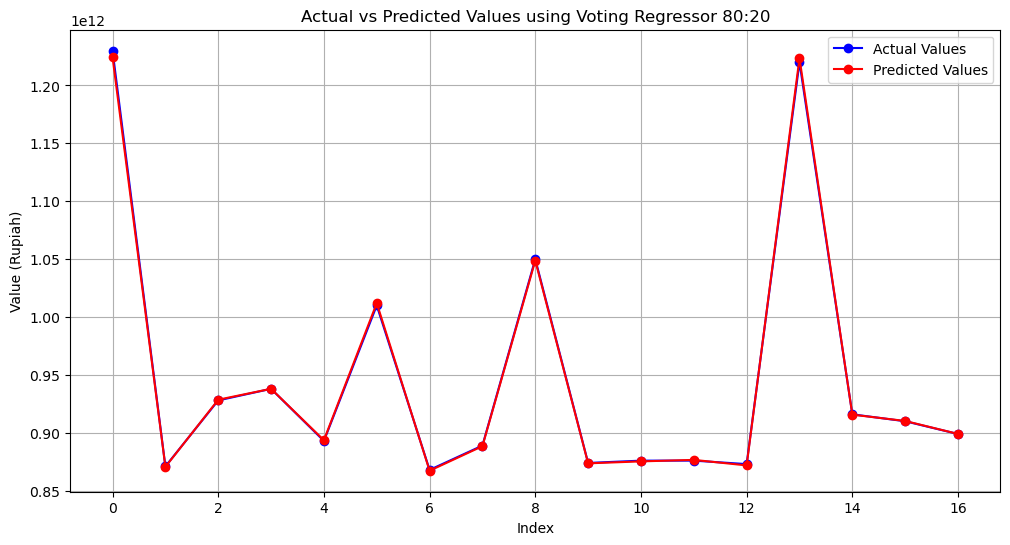

In [50]:
# Predict on the test data
y_pred_log2 = voting_regressor2.predict(X_test2)

# If your target variable was log-transformed, revert it back
y_actual2 = np.exp(y_test2.reset_index(drop=True))
y_pred2 = np.exp(y_pred_log2)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_actual2,
    'Predicted': y_pred2
})

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 'bo-', label='Actual Values')
plt.plot(comparison_df.index, comparison_df['Predicted'], 'ro-', label='Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value (Rupiah)')
plt.title(f'Actual vs Predicted Values using Voting Regressor 80:20')
plt.legend()
plt.grid(True)
plt.show()


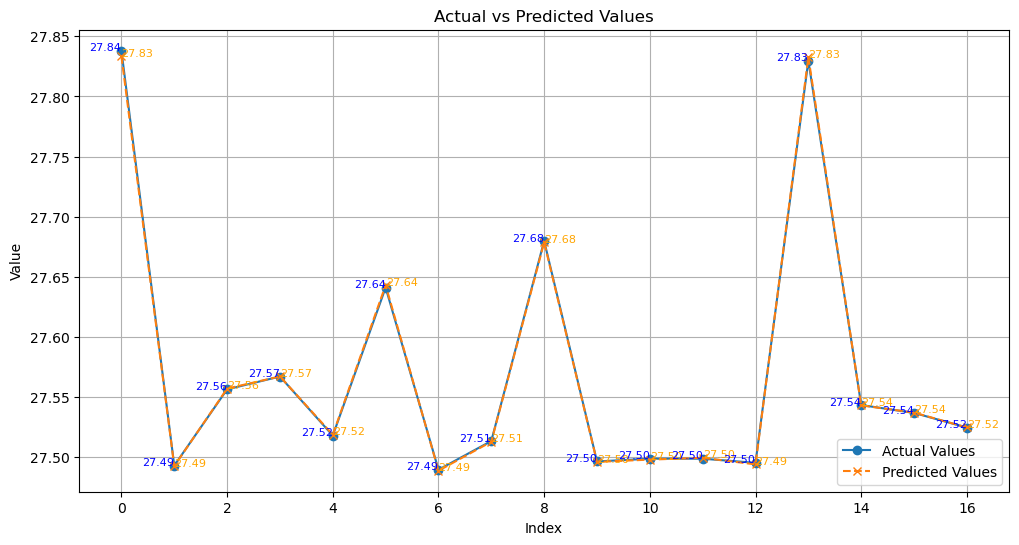

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Pastikan data berbentuk array (jika tidak, ubah dengan np.array)
y_test_voting2 = np.array(y_test2)  # Nilai aktual
y_pred_voting2 = np.array(y_pred_log2)  # Nilai prediksi

# Buat plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test_voting2)), y_test_voting2, label='Actual Values', marker='o', linestyle='-')
plt.plot(range(len(y_pred_voting2)), y_pred_voting2, label='Predicted Values', marker='x', linestyle='--')

# Tambahkan angka di setiap titik
for i, (y_actual, y_predict) in enumerate(zip(y_test_voting2, y_pred_voting2)):
    plt.text(i, y_actual, f'{y_actual:.2f}', fontsize=8, ha='right', color='blue')
    plt.text(i, y_predict, f'{y_predict:.2f}', fontsize=8, ha='left', color='orange')

# Tambahkan label dan judul
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)

# Tampilkan plot
plt.show()

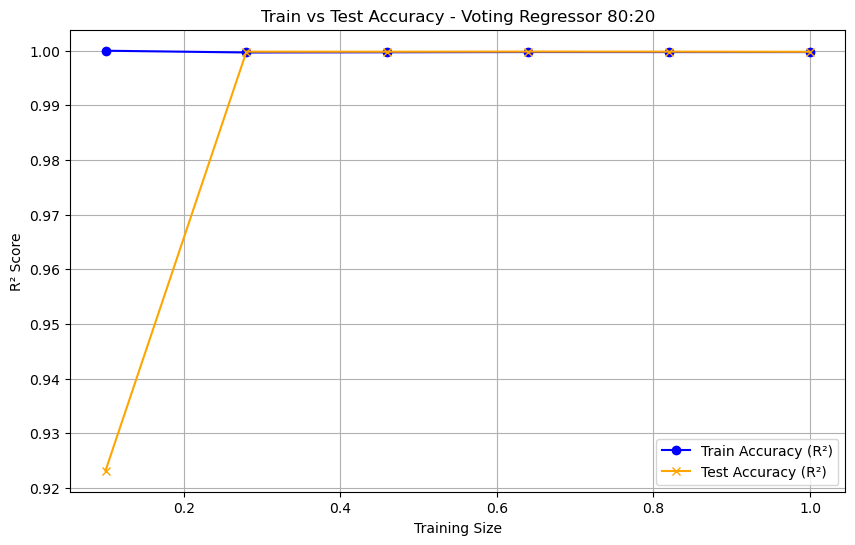

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Training sizes (misalnya dalam persen data training)
training_sizes_voting2 = np.linspace(0.1, 1.0, 6)

# Menyimpan nilai R² untuk setiap training size
train_accuracies_best_voting2 = []
test_accuracies_best_voting2 = []

for size in training_sizes_voting2:
    # Tentukan jumlah data training sesuai ukuran
    train_size_voting2 = int(size * len(X_train2))
    X_train_subset_voting2 = X_train2[:train_size_voting2]
    y_train_subset_voting2 = y_train2[:train_size_voting2]
    
    # Fit model dengan subset data
    voting_regressor2.fit(X_train_subset_voting2, y_train_subset_voting2)
    
    # Prediksi untuk data training dan testing
    y_train_pred_voting2 = voting_regressor2.predict(X_train_subset_voting2)
    y_test_pred_voting2 = voting_regressor2.predict(X_test2)
    
    # Hitung R² Score
    train_accuracies_best_voting2.append(r2_score(y_train_subset_voting2, y_train_pred_voting2))
    test_accuracies_best_voting2.append(r2_score(y_test2, y_test_pred_voting2))

# Plot Train vs Test Accuracy khusus model terbaik
plt.figure(figsize=(10, 6))
plt.plot(training_sizes_voting2, train_accuracies_best_voting2, 'bo-', label='Train Accuracy (R²)')
plt.plot(training_sizes_voting2, test_accuracies_best_voting2, 'x-', color='orange', label='Test Accuracy (R²)')
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.title(f'Train vs Test Accuracy - Voting Regressor 80:20')
plt.grid(True)
plt.legend()
plt.show()


Cross Validation Voting Regressor

In [57]:
from sklearn.model_selection import cross_val_score

# Model terbaik
# best_model_name = results_df2.iloc[0]['Model']
# best_model = models2[best_model_name]

# Cross-validation
cv_folds = 5  # Jumlah lipatan (folds)
cv_scores = cross_val_score(voting_regressor2, X1, y1, cv=cv_folds, scoring='r2', )

# Rata-rata dan standar deviasi R² Score dari cross-validation
mean_cv_score = np.mean(cv_scores)
std_cv_score = np.std(cv_scores)

# Tampilkan hasil
print(f"Cross-Validation Scores (R²): {cv_scores}")
print(f"Mean R² Score: {mean_cv_score:.4f}")
print(f"Standard Deviation: {std_cv_score:.4f}")


Cross-Validation Scores (R²): [0.99928552 0.9997762  0.99968665 0.99969922 0.99666373]
Mean R² Score: 0.9990
Standard Deviation: 0.0012


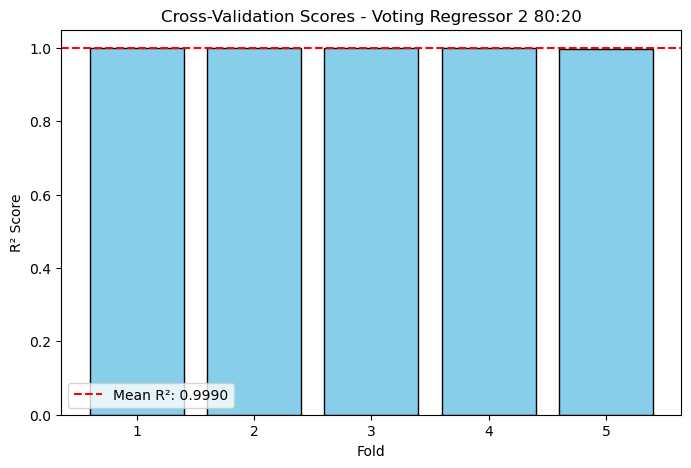

In [58]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, cv_folds + 1), cv_scores, color='skyblue', edgecolor='black')
plt.axhline(y=mean_cv_score, color='red', linestyle='--', label=f"Mean R²: {mean_cv_score:.4f}")
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title(f'Cross-Validation Scores - Voting Regressor 2 80:20')
plt.legend()
plt.show()


In [59]:
from joblib import dump, load

# Simpan model ke file
dump(voting_regressor2, '../model/voting_regressor2_model.joblib')

print("Model berhasil disimpan!")


Model berhasil disimpan!


In [60]:
# Simpan scaler
dump(scalerMinMax, '../model/scaler.pkl')
print("Scaler berhasil disimpan!")

Scaler berhasil disimpan!


In [61]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from joblib import dump

# Membuat encoder untuk kolom kategorikal
encoder_namaproyek = LabelEncoder()
encoder_provinsi = LabelEncoder()

# Fit encoder pada data pelatihan
data_cleaned['namaproyek'] = encoder_namaproyek.fit_transform(data_cleaned['namaproyek'])
data_cleaned['provinsi'] = encoder_provinsi.fit_transform(data_cleaned['provinsi'])

# Simpan encoder
dump(encoder_namaproyek, '../model/encoder_namaproyek.pkl')
dump(encoder_provinsi, '../model/encoder_provinsi.pkl')
print("Encoder berhasil disimpan!")

Encoder berhasil disimpan!
